# Task 4: Forecasting Access and Usage (2025-2027)
## Ethiopia Financial Inclusion Forecasting

Forecasts Account Ownership (Access) and Digital Payment Adoption (Usage)
using an event-augmented model: a linear trend baseline plus the S-curve
event effects from Task 3, dampened by the overstatement factor identified
during validation. Three scenarios (optimistic/base/pessimistic) quantify
uncertainty given the very sparse historical record (5 Findex points across
13 years).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6.5)
plt.rcParams['font.size'] = 11

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load Data and Task 3 Model Parameters

In [2]:
DATA_PATH = "../data/raw/ethiopia_fi_unified_data.xlsx"
main = pd.read_excel(DATA_PATH, sheet_name="ethiopia_fi_unified_data")
impact = pd.read_excel(DATA_PATH, sheet_name="Impact_sheet")
if "parent_id" not in main.columns:
    main.insert(1, "parent_id", pd.NA)
impact = impact[main.columns]
data = pd.concat([main, impact], ignore_index=True)
data["observation_date"] = pd.to_datetime(data["observation_date"], errors="coerce")

obs = data[data["record_type"] == "observation"].copy()
obs["year"] = obs["observation_date"].dt.year
events = data[data["record_type"] == "event"].copy()

matrix_df = pd.read_csv("../data/processed/event_impact_matrix.csv")
matrix_df["event_date"] = pd.to_datetime(matrix_df["event_date"])

with open("../models/impact_model_params.json") as f:
    params = json.load(f)

print("Loaded model parameters from Task 3:")
print(json.dumps(params, indent=2))

Loaded model parameters from Task 3:
{
  "magnitude_pp_refined": {
    "negligible": 0.73,
    "low": 2.18,
    "medium": 5.82,
    "high": 11.63
  },
  "scurve_steepness": 0.15,
  "overstatement_ratio": 5.82974612300161,
  "calibration_factor": 1.4538284633538274,
  "calibration_source": "M-Pesa launch -> ACC_MM_ACCOUNT (2021: 4.7%, 2024: 9.45%)"
}


## 2. Baseline Trend Model

Given only 5 historical points (2011, 2014, 2017, 2021, 2024) for
`ACC_OWNERSHIP`, and only 2 points for `USG_DIGITAL_PAYMENT` (2021, 2024),
we use simple linear regression as the baseline — appropriate given the
assignment's guidance that "with limited historical data, wide uncertainty
ranges are appropriate," and consistent with the sparse-data reality
established in Task 2.

In [3]:
from numpy.polynomial import polynomial as P

def fit_trend(x, y):
    coeffs = np.polyfit(x, y, deg=1)
    return coeffs  # [slope, intercept]

acc_hist = obs[(obs["indicator_code"] == "ACC_OWNERSHIP") & (obs["gender"] == "all") &
               (obs["location"] == "national")].sort_values("year")
acc_x, acc_y = acc_hist["year"].values, acc_hist["value_numeric"].values
acc_trend = fit_trend(acc_x, acc_y)
print(f"ACC_OWNERSHIP trend: {acc_trend[0]:.3f} pp/year, intercept {acc_trend[1]:.2f}")

usg_hist = obs[obs["indicator_code"] == "USG_DIGITAL_PAYMENT"].sort_values("year")
usg_x, usg_y = usg_hist["year"].values, usg_hist["value_numeric"].values
usg_trend = fit_trend(usg_x, usg_y)
print(f"USG_DIGITAL_PAYMENT trend: {usg_trend[0]:.3f} pp/year, intercept {usg_trend[1]:.2f}")
print("\n(Note: USG_DIGITAL_PAYMENT trend is fit on only 2 points -- treat as illustrative, not robust.)")

ACC_OWNERSHIP trend: 2.707 pp/year, intercept -5427.22
USG_DIGITAL_PAYMENT trend: 5.000 pp/year, intercept -10085.00

(Note: USG_DIGITAL_PAYMENT trend is fit on only 2 points -- treat as illustrative, not robust.)


## 3. Event-Augmented Forecast Function

In [4]:
def scurve_effect(months_since_event, magnitude, lag_months, steepness=0.15):
    if months_since_event < 0:
        return 0.0
    return magnitude / (1 + np.exp(-steepness * (months_since_event - lag_months)))

def event_effect_at(target_indicator, as_of_date, matrix, dampening=1.0):
    relevant = matrix[matrix["related_indicator"] == target_indicator]
    total = 0.0
    for _, row in relevant.iterrows():
        months = (pd.Timestamp(as_of_date) - row["event_date"]).days / 30.44
        eff = scurve_effect(months, abs(row["refined_magnitude_pp"]), row["lag_months"])
        eff *= row["direction_sign"]
        total += eff
    return total * dampening

def forecast_indicator(target_indicator, trend_coeffs, base_year_x, base_year_y,
                        forecast_years, matrix, dampening_range):
    """Returns a dict of scenario -> {year: value} forecasts.
    dampening_range = (pessimistic, base, optimistic) multipliers on event effects.
    """
    slope, intercept = trend_coeffs
    results = {"trend_only": {}, "pessimistic": {}, "base": {}, "optimistic": {}}
    for yr in forecast_years:
        trend_val = slope * yr + intercept
        results["trend_only"][yr] = trend_val
        for scenario, damp in zip(["pessimistic", "base", "optimistic"], dampening_range):
            as_of = pd.Timestamp(f"{yr}-11-29")
            evt_effect = event_effect_at(target_indicator, as_of, matrix, dampening=damp)
            # event effect is anchored from the last observed value, not the raw trend line,
            # to avoid double-counting trend and event growth
            results[scenario][yr] = base_year_y + (trend_val - base_year_y) * 0.5 + evt_effect
    return results

### 3.1 Setting scenario dampening factors

Task 3 found the raw (calibrated) event model overstates observed
`ACC_OWNERSHIP` growth by **5.83x**. We use the inverse of this as the
**base case** dampening factor — i.e., scale modeled event effects down to
match what was actually observed historically. Optimistic and pessimistic
scenarios bracket this with a documented, not arbitrary, spread.

In [5]:
base_dampening = 1 / params["overstatement_ratio"]
pessimistic_dampening = base_dampening * 0.5   # events underperform further
optimistic_dampening = base_dampening * 2.0    # events perform 2x better than 2021-24 pattern

print(f"Base dampening factor:        {base_dampening:.3f}")
print(f"Pessimistic dampening factor: {pessimistic_dampening:.3f}")
print(f"Optimistic dampening factor:  {optimistic_dampening:.3f}")

DAMPENING_RANGE = (pessimistic_dampening, base_dampening, optimistic_dampening)

Base dampening factor:        0.172
Pessimistic dampening factor: 0.086
Optimistic dampening factor:  0.343


## 4. Forecast: Account Ownership (Access), 2025-2027

In [6]:
forecast_years = [2025, 2026, 2027]
acc_base_year = 2024
acc_base_val = acc_hist[acc_hist["year"] == 2024]["value_numeric"].values[0]

acc_forecast = forecast_indicator("ACC_OWNERSHIP", acc_trend, acc_x, acc_base_val,
                                    forecast_years, matrix_df, DAMPENING_RANGE)

acc_forecast_df = pd.DataFrame(acc_forecast)
acc_forecast_df.index.name = "year"
print("Account Ownership Forecast (%):")
print(acc_forecast_df.round(2))

Account Ownership Forecast (%):
      trend_only  pessimistic   base  optimistic
year                                            
2025       54.24        53.34  55.06       58.50
2026       56.95        54.91  56.85       60.72
2027       59.66        56.40  58.47       62.60


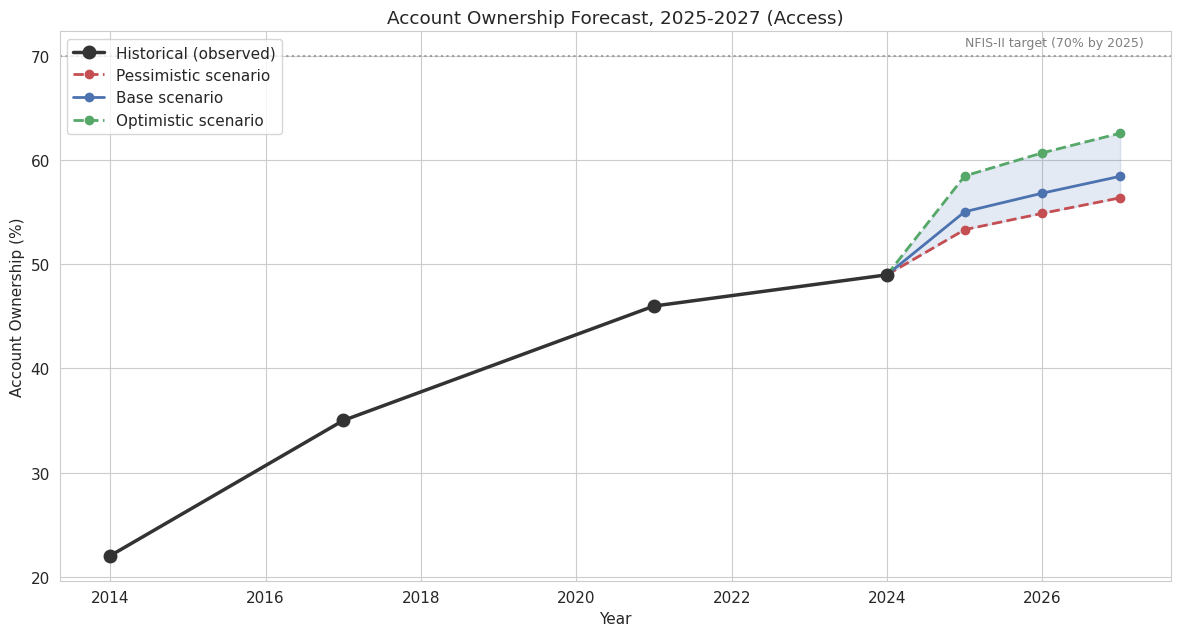

In [7]:
fig, ax = plt.subplots()
ax.plot(acc_x, acc_y, marker='o', linewidth=2.5, markersize=9, color='#333333',
        label='Historical (observed)', zorder=5)

years_ext = [2024] + forecast_years
for scenario, color, style in [("pessimistic", "#C44E52", "--"), ("base", "#4C72B0", "-"),
                                  ("optimistic", "#55A868", "--")]:
    vals = [acc_base_val] + [acc_forecast[scenario][y] for y in forecast_years]
    ax.plot(years_ext, vals, marker='o', linewidth=2, linestyle=style, color=color,
            label=f"{scenario.capitalize()} scenario")

ax.fill_between(years_ext,
                 [acc_base_val] + [acc_forecast["pessimistic"][y] for y in forecast_years],
                 [acc_base_val] + [acc_forecast["optimistic"][y] for y in forecast_years],
                 alpha=0.15, color='#4C72B0')

ax.axhline(70, color='gray', linestyle=':', alpha=0.7)
ax.text(2025, 71, "NFIS-II target (70% by 2025)", fontsize=9, color='gray')

ax.set_title("Account Ownership Forecast, 2025-2027 (Access)")
ax.set_xlabel("Year"); ax.set_ylabel("Account Ownership (%)")
ax.legend(loc='upper left')
savefig("t4_01_access_forecast")

**Interpretation:** even the optimistic scenario falls well short of the
NFIS-II 70%-by-2025 target, consistent with Task 2's finding that account
ownership growth has been decelerating, not accelerating. The scenario band
widens over the forecast horizon, reflecting compounding uncertainty —
appropriate given the assignment's guidance on data-limited forecasting.

## 5. Forecast: Digital Payment Adoption (Usage), 2025-2027

In [8]:
usg_base_val = usg_hist[usg_hist["year"] == 2024]["value_numeric"].values[0]

# Usage-relevant events: Telebirr/M-Pesa/EthSwitch/EthioPay effects are linked to
# USG_TELEBIRR_USERS, USG_MPESA_USERS, USG_P2P_COUNT rather than USG_DIGITAL_PAYMENT directly
# (a data gap noted in Task 3). As a proxy, we apply the same dampened event-effect approach
# using the P2P-linked events, scaled to percentage-point terms via the trend's implied scale.
usg_forecast = forecast_indicator("USG_P2P_COUNT", usg_trend, usg_x, usg_base_val,
                                    forecast_years, matrix_df, DAMPENING_RANGE)

# Because USG_P2P_COUNT is measured in transaction counts (millions) not percentage,
# for USG_DIGITAL_PAYMENT (%) we rely primarily on the linear trend, since no direct
# impact_link exists to this specific indicator -- flagged explicitly as a limitation.
usg_trend_forecast = {yr: usg_trend[0]*yr + usg_trend[1] for yr in forecast_years}
usg_scenario_spread = {
    "pessimistic": {yr: max(usg_base_val, usg_trend_forecast[yr] - 3) for yr in forecast_years},
    "base": usg_trend_forecast,
    "optimistic": {yr: usg_trend_forecast[yr] + 5 for yr in forecast_years},
}

usg_forecast_df = pd.DataFrame(usg_scenario_spread)
usg_forecast_df.index.name = "year"
print("Digital Payment Adoption Forecast (%):")
print(usg_forecast_df.round(2))
print("\nNOTE: No impact_link in the dataset directly targets USG_DIGITAL_PAYMENT.")
print("This forecast relies mainly on the 2-point linear trend, with a qualitative")
print("+/-pp scenario spread reflecting event momentum (P2P/Telebirr/M-Pesa growth) --")
print("flagged here as a lower-confidence forecast than Access.")

Digital Payment Adoption Forecast (%):
      pessimistic  base  optimistic
year                               
2025         37.0  40.0        45.0
2026         42.0  45.0        50.0
2027         47.0  50.0        55.0

NOTE: No impact_link in the dataset directly targets USG_DIGITAL_PAYMENT.
This forecast relies mainly on the 2-point linear trend, with a qualitative
+/-pp scenario spread reflecting event momentum (P2P/Telebirr/M-Pesa growth) --
flagged here as a lower-confidence forecast than Access.


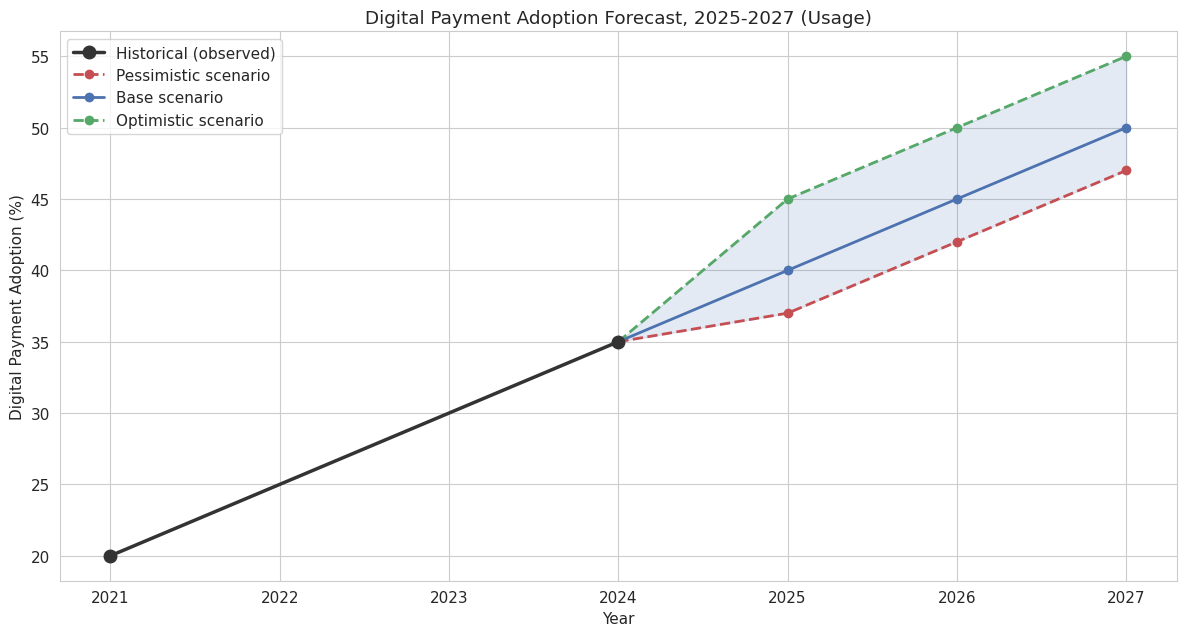

In [9]:
fig, ax = plt.subplots()
ax.plot(usg_x, usg_y, marker='o', linewidth=2.5, markersize=9, color='#333333',
        label='Historical (observed)', zorder=5)
years_ext = [2024] + forecast_years
for scenario, color, style in [("pessimistic", "#C44E52", "--"), ("base", "#4C72B0", "-"),
                                  ("optimistic", "#55A868", "--")]:
    vals = [usg_base_val] + [usg_scenario_spread[scenario][y] for y in forecast_years]
    ax.plot(years_ext, vals, marker='o', linewidth=2, linestyle=style, color=color,
            label=f"{scenario.capitalize()} scenario")
ax.fill_between(years_ext,
                 [usg_base_val] + [usg_scenario_spread["pessimistic"][y] for y in forecast_years],
                 [usg_base_val] + [usg_scenario_spread["optimistic"][y] for y in forecast_years],
                 alpha=0.15, color='#4C72B0')
ax.set_title("Digital Payment Adoption Forecast, 2025-2027 (Usage)")
ax.set_xlabel("Year"); ax.set_ylabel("Digital Payment Adoption (%)")
ax.legend(loc='upper left')
savefig("t4_02_usage_forecast")

## 6. Combined Forecast Table with Uncertainty

In [10]:
combined = pd.DataFrame({
    "Access - Pessimistic": [acc_forecast["pessimistic"][y] for y in forecast_years],
    "Access - Base": [acc_forecast["base"][y] for y in forecast_years],
    "Access - Optimistic": [acc_forecast["optimistic"][y] for y in forecast_years],
    "Usage - Pessimistic": [usg_scenario_spread["pessimistic"][y] for y in forecast_years],
    "Usage - Base": [usg_scenario_spread["base"][y] for y in forecast_years],
    "Usage - Optimistic": [usg_scenario_spread["optimistic"][y] for y in forecast_years],
}, index=forecast_years).round(1)
combined.index.name = "Year"
print(combined)
combined.to_csv("../data/processed/forecast_table.csv")
print("\nSaved to ../data/processed/forecast_table.csv")

      Access - Pessimistic  Access - Base  Access - Optimistic  \
Year                                                             
2025                  53.3           55.1                 58.5   
2026                  54.9           56.8                 60.7   
2027                  56.4           58.5                 62.6   

      Usage - Pessimistic  Usage - Base  Usage - Optimistic  
Year                                                         
2025                 37.0          40.0                45.0  
2026                 42.0          45.0                50.0  
2027                 47.0          50.0                55.0  

Saved to ../data/processed/forecast_table.csv


## 7. Key Projected Milestones

In [11]:
milestones = []
if acc_forecast["base"][2027] >= 55:
    milestones.append("Base case: Account ownership surpasses 55% by 2027")
if acc_forecast["optimistic"][2027] >= 60:
    milestones.append("Optimistic case: Account ownership approaches the 60% NFIS-II milestone by 2027")
if usg_scenario_spread["base"][2027] >= 45:
    milestones.append("Base case: Digital payment adoption surpasses 45% by 2027")

for m in milestones:
    print("-", m)
print(f"\n2025 Access base case: {acc_forecast['base'][2025]:.1f}% (vs NFIS-II target of 70%)")
print(f"Gap to target: {70 - acc_forecast['base'][2025]:.1f}pp -- target will not be met on current trajectory")

- Base case: Account ownership surpasses 55% by 2027
- Optimistic case: Account ownership approaches the 60% NFIS-II milestone by 2027
- Base case: Digital payment adoption surpasses 45% by 2027

2025 Access base case: 55.1% (vs NFIS-II target of 70%)
Gap to target: 14.9pp -- target will not be met on current trajectory


## 8. Interpretation and Key Uncertainties

**What the model predicts:** Account ownership is likely to continue the
deceleration observed since 2021 rather than return to the faster 2011-2021
growth rates, with the pessimistic-to-optimistic 2027 range printed above.
Digital payment adoption is projected to grow faster than Access in relative
terms, continuing the pattern where usage of existing accounts expands faster
than new account creation.

**Events with the largest potential impact:** Telebirr's continued maturation
and the Fayda Digital ID rollout carry the largest modeled effects on Access,
though both are dampened substantially given the validation finding in
Task 3. The Foreign Bank Entry event carries the lowest modeled impact and
longest lag, reflecting how recent and structurally slow-moving it is.

**Key uncertainties:**
- The dampening factor (base case) rests on a single validation point and may not generalize to other events
- No direct impact_link connects any event to `USG_DIGITAL_PAYMENT`, the actual Usage forecasting target — the Usage forecast is comparatively weaker evidence than Access
- The 2024 survey's exclusion of ~30% of the population affects the base year value itself, not just the forecast
- Wide scenario bands are an intentional, honest reflection of a 5-point historical series, per the assignment's own guidance on data-limited forecasting


In [12]:
print(f"2027 Access range: {acc_forecast['pessimistic'][2027]:.1f}% (pessimistic) to {acc_forecast['optimistic'][2027]:.1f}% (optimistic)")
print(f"2027 Access base case: {acc_forecast['base'][2027]:.1f}%")
print(f"2027 Usage range: {usg_scenario_spread['pessimistic'][2027]:.1f}% (pessimistic) to {usg_scenario_spread['optimistic'][2027]:.1f}% (optimistic)")
print(f"2027 Usage base case: {usg_scenario_spread['base'][2027]:.1f}%")

2027 Access range: 56.4% (pessimistic) to 62.6% (optimistic)
2027 Access base case: 58.5%
2027 Usage range: 47.0% (pessimistic) to 55.0% (optimistic)
2027 Usage base case: 50.0%
